# Geo-FNO Mapping + Grid Diagnostics

This notebook runs two targeted diagnostics:

1. **Mapped point-cloud check**: plot `xi = iphi(x, code)` and quantify local distortion/collapse.
2. **Uniform-grid tensor check**: inspect the tensor fed into `conv1` (the uniform computational grid after `conv0 + b0 + GELU`).

Interpretation guide is at the bottom.

In [1]:
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.tri as tri

from geo_FNO_def import FNO2d, IPHI, get_global_L_from_h5

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


In [2]:
# ----------------------------
# Config
# ----------------------------
H5_PATH = '/scratch/mnhagen/datasets/incompressible_euler/test.h5'
FNO_CKPT  = '/scratch/mnhagen/models/geofno/cylinder_vel_t0_t-1_fno.pt'
IPHI_CKPT = '/scratch/mnhagen/models/geofno/cylinder_vel_t0_t-1_iphi.pt'

t_in = 0
t_out = -1

# Must match training
modes = 20
width = 32
s1 = 80
s2 = 40

# Diagnostics
sample_indices = [0, 1, 2, 10, 20]   # change as needed
k_nn = 3                              # for local distance ratio

boundary_label = 6
band_frac = 0.06


In [3]:
# ----------------------------
# Helpers
# ----------------------------
def fit_circle_kasa(x, y):
    A = np.stack([x, y, np.ones_like(x)], axis=1)
    b = -(x**2 + y**2)
    sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    a, b_, c = sol
    xc = -a / 2.0
    yc = -b_ / 2.0
    r2 = (a * a + b_ * b_) / 4.0 - c
    return float(xc), float(yc), float(np.sqrt(max(r2, 0.0)))

def estimate_cylinder_from_label6(pos, node_type, boundary_label=6, band_frac=0.06):
    xy = pos[node_type == boundary_label]
    y = xy[:, 1]
    ymin, ymax = float(y.min()), float(y.max())
    band = band_frac * (ymax - ymin)
    mask = (y > ymin + band) & (y < ymax - band)
    xy_cyl = xy[mask]
    return fit_circle_kasa(xy_cyl[:, 0], xy_cyl[:, 1])

def local_knn_distance_ratio(x, xi, k=3):
    # x, xi: torch tensors (N,2)
    dx = torch.cdist(x, x)
    dxi = torch.cdist(xi, xi)

    # ignore self-distances by setting diagonal to +inf
    inf = torch.tensor(float('inf'), device=x.device, dtype=x.dtype)
    dx.fill_diagonal_(inf)
    dxi.fill_diagonal_(inf)

    # kth nearest neighbor distance
    d_x = torch.topk(dx, k=k, largest=False).values[:, -1]
    d_xi = torch.topk(dxi, k=k, largest=False).values[:, -1]
    ratio = d_xi / (d_x + 1e-12)
    return ratio

def load_model_and_iphi(h5_path):
    L_global, key_used = get_global_L_from_h5(h5_path)
    print('Using L_global from', key_used, ':', L_global)

    model = FNO2d(
        modes, modes, width,
        in_channels=2, out_channels=2,
        is_mesh=False, s1=s1, s2=s2,
        L=L_global
    ).to(device)
    model_iphi = IPHI(width=32, device=str(device)).to(device)

    model.load_state_dict(torch.load(FNO_CKPT, map_location=device), strict=False)
    model_iphi.load_state_dict(torch.load(IPHI_CKPT, map_location=device), strict=False)
    model.eval()
    model_iphi.eval()
    return model, model_iphi

def get_sample_dict(h5_path, idx):
    with h5py.File(h5_path, 'r') as f:
        keys = sorted([k for k in f.keys() if k.startswith('sample_')])
        k = keys[idx]
        g = f[k]
        pos = g['pos'][:].astype(np.float32)
        node_type = g['node_type'][:]
        vel = g['vel'][:]
        u_in = vel[t_in].astype(np.float32)
        u_out = vel[t_out].astype(np.float32)
        xc, yc, r = estimate_cylinder_from_label6(pos, node_type, boundary_label=boundary_label, band_frac=band_frac)
        code = np.zeros((42,), dtype=np.float32)
        code[0], code[1], code[2] = xc, yc, r
        return {
            'key': k,
            'pos': pos,
            'u_in': u_in,
            'u_out': u_out,
            'code': code,
            'xc': xc,
            'yc': yc,
            'r': r,
        }


In [4]:
model, model_iphi = load_model_and_iphi(H5_PATH)


Using L_global from sample_000000 : [1.600000023841858, 0.4099999964237213]


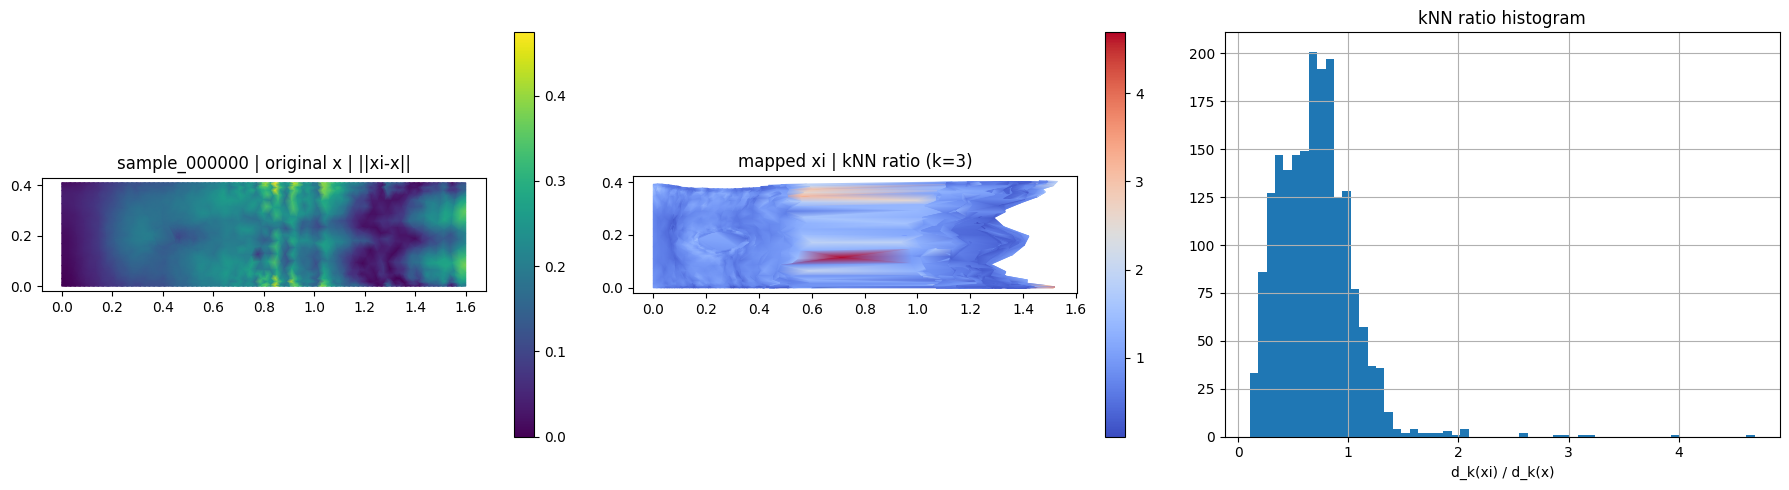

sample_000000 ratio quantiles: 1%=1.552e-01, 5%=2.428e-01, 50%=6.928e-01, 95%=1.209e+00, 99%=1.713e+00
sample_000000 disp mean=1.569e-01, max=4.744e-01


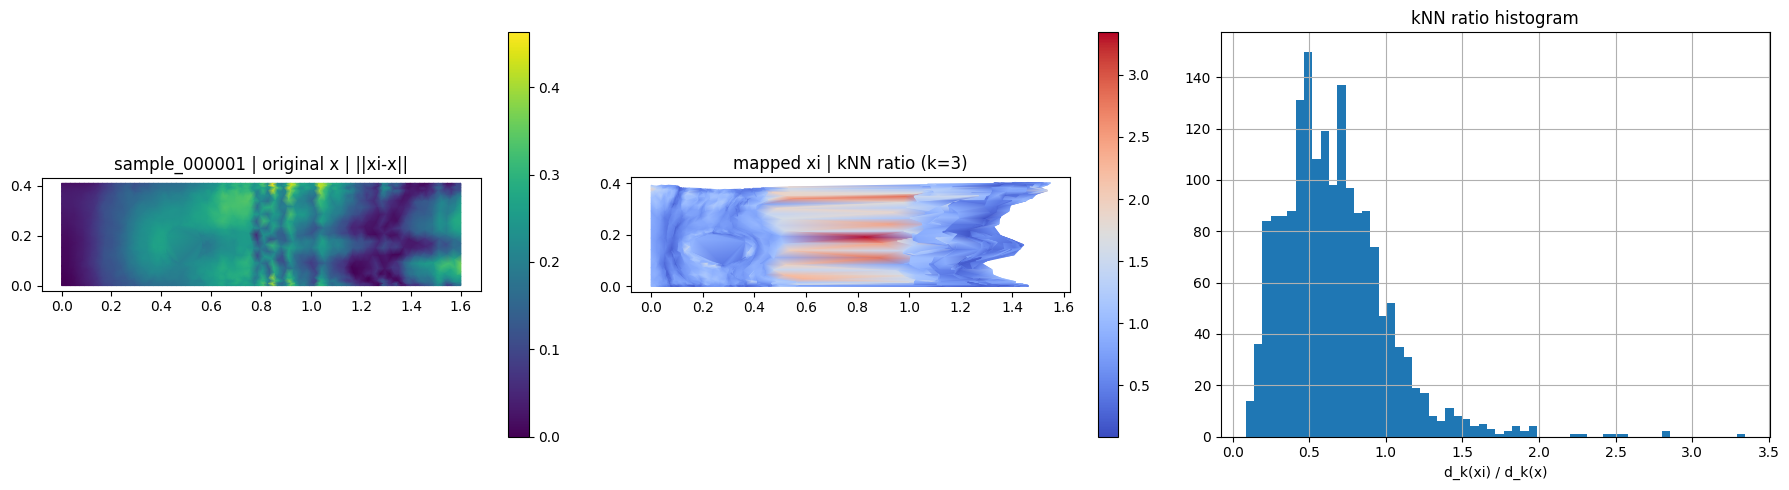

sample_000001 ratio quantiles: 1%=1.530e-01, 5%=2.216e-01, 50%=6.206e-01, 95%=1.233e+00, 99%=1.834e+00
sample_000001 disp mean=1.692e-01, max=4.629e-01


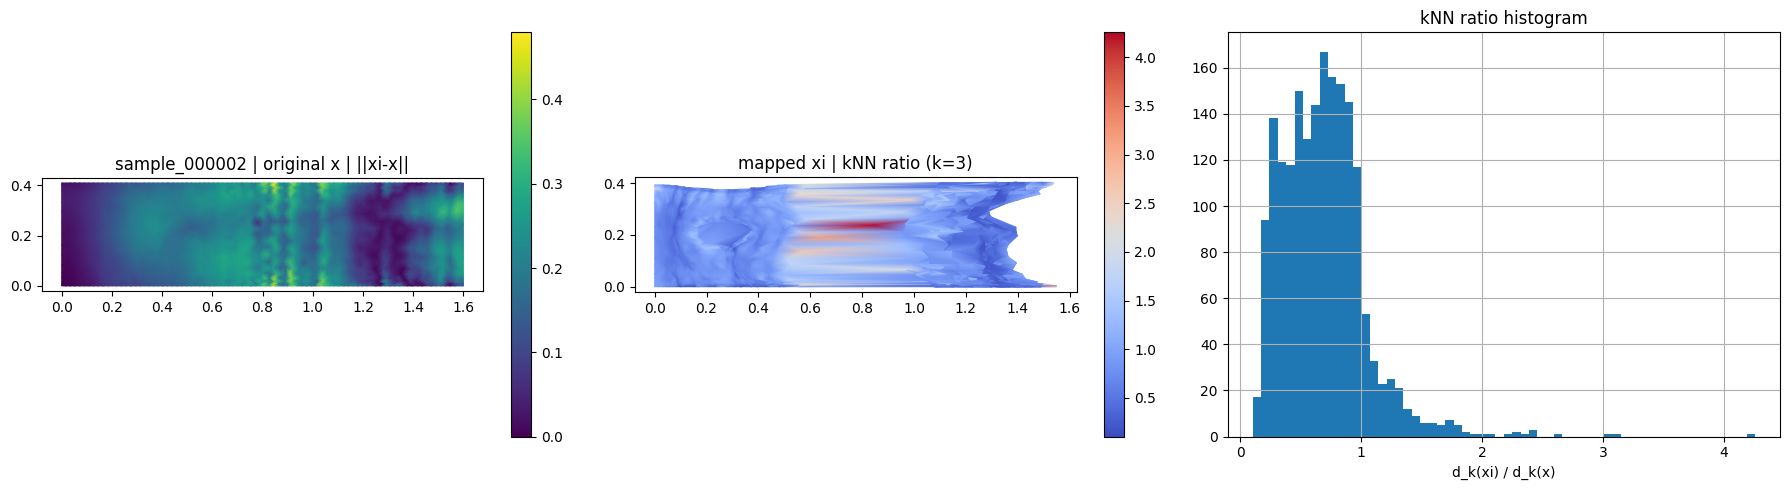

sample_000002 ratio quantiles: 1%=1.741e-01, 5%=2.321e-01, 50%=6.643e-01, 95%=1.260e+00, 99%=1.786e+00
sample_000002 disp mean=1.653e-01, max=4.797e-01


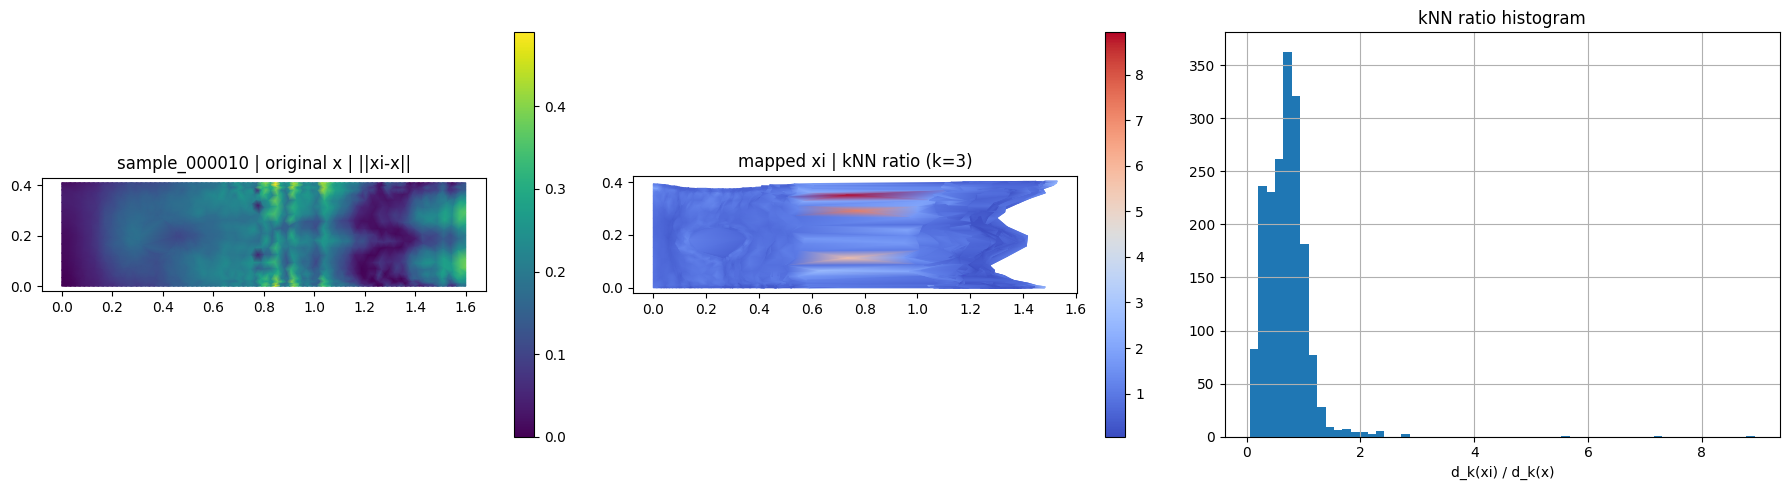

sample_000010 ratio quantiles: 1%=1.300e-01, 5%=2.135e-01, 50%=6.892e-01, 95%=1.164e+00, 99%=1.869e+00
sample_000010 disp mean=1.509e-01, max=4.898e-01


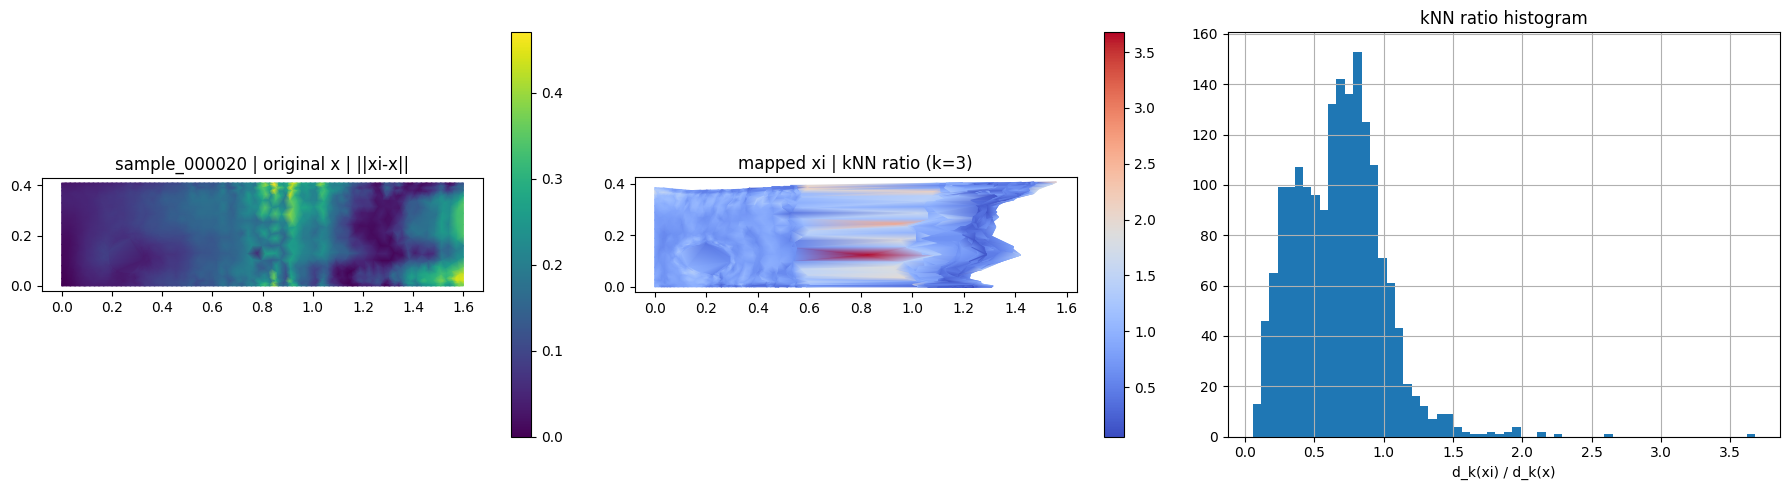

sample_000020 ratio quantiles: 1%=1.293e-01, 5%=2.122e-01, 50%=6.800e-01, 95%=1.163e+00, 99%=1.567e+00
sample_000020 disp mean=1.290e-01, max=4.704e-01


In [5]:
# ----------------------------
# Diagnostic 1: mapped cloud xi = iphi(x, code)
# ----------------------------
for idx in sample_indices:
    s = get_sample_dict(H5_PATH, idx)
    pos = torch.from_numpy(s['pos']).unsqueeze(0).to(device)
    code = torch.from_numpy(s['code']).unsqueeze(0).to(device)

    with torch.no_grad():
        xi = model_iphi(pos, code).squeeze(0)

    x = pos.squeeze(0)
    ratio = local_knn_distance_ratio(x, xi, k=k_nn).detach().cpu().numpy()
    disp = torch.norm((xi - x), dim=-1).detach().cpu().numpy()

    x_np = x.detach().cpu().numpy()
    xi_np = xi.detach().cpu().numpy()

    tri_x = tri.Triangulation(x_np[:, 0], x_np[:, 1])
    tri_xi = tri.Triangulation(xi_np[:, 0], xi_np[:, 1], triangles=tri_x.triangles)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    t0 = axes[0].tripcolor(tri_x, disp, shading='gouraud', cmap='viridis')
    axes[0].set_title(f"{s['key']} | original x | ||xi-x||")
    axes[0].set_aspect('equal')
    fig.colorbar(t0, ax=axes[0])

    t1 = axes[1].tripcolor(tri_xi, ratio, shading='gouraud', cmap='coolwarm')
    axes[1].set_title(f"mapped xi | kNN ratio (k={k_nn})")
    axes[1].set_aspect('equal')
    fig.colorbar(t1, ax=axes[1])

    axes[2].hist(ratio, bins=60)
    axes[2].set_title('kNN ratio histogram')
    axes[2].set_xlabel('d_k(xi) / d_k(x)')

    plt.tight_layout()
    plt.show()

    q = np.quantile(ratio, [0.01, 0.05, 0.5, 0.95, 0.99])
    print(f"{s['key']} ratio quantiles: 1%={q[0]:.3e}, 5%={q[1]:.3e}, 50%={q[2]:.3e}, 95%={q[3]:.3e}, 99%={q[4]:.3e}")
    print(f"{s['key']} disp mean={disp.mean():.3e}, max={disp.max():.3e}")


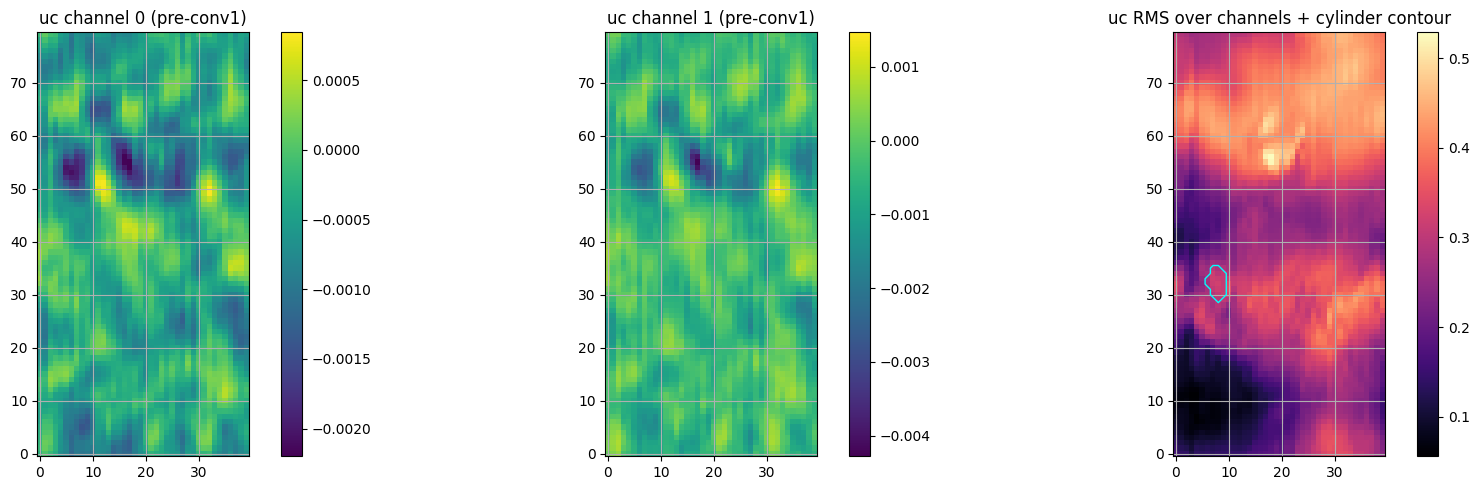

sample: sample_000000
uc shape: (32, 80, 40)
inside mean |uc|: 3.040e-01
outside mean |uc|: 2.961e-01
inside/outside energy ratio: 1.027e+00
channel std stats: min=1.060e-04, median=9.670e-04, max=5.439e-01


In [6]:
# ----------------------------
# Diagnostic 2: tensor on uniform grid right before conv1
# ----------------------------
sample_for_grid = sample_indices[0]
s = get_sample_dict(H5_PATH, sample_for_grid)

pos_t = torch.from_numpy(s['pos']).unsqueeze(0).to(device)
uin_t = torch.from_numpy(s['u_in']).unsqueeze(0).to(device)
code_t = torch.from_numpy(s['code']).unsqueeze(0).to(device)

capt = {}
def conv1_prehook(module, inputs):
    # inputs[0] is uc, shape (B,C,s1,s2)
    capt['uc_preconv1'] = inputs[0].detach().cpu()

h = model.conv1.register_forward_pre_hook(conv1_prehook)
with torch.no_grad():
    _ = model(uin_t, code=code_t, x_in=pos_t, x_out=pos_t, iphi=model_iphi)
h.remove()

uc = capt['uc_preconv1'][0]  # (C,s1,s2)
uc_norm = torch.sqrt(torch.mean(uc ** 2, dim=0)).numpy()  # (s1,s2)
ch0 = uc[0].numpy()
ch1 = uc[1].numpy()

grid = model.get_grid([1, model.s1, model.s2], device).cpu().numpy()[0]  # (s1,s2,2)
gx = grid[..., 0]
gy = grid[..., 1]
rad = np.sqrt((gx - s['xc']) ** 2 + (gy - s['yc']) ** 2)
inside = rad <= s['r']

inside_energy = float(np.mean(np.abs(uc_norm[inside]))) if np.any(inside) else np.nan
outside_energy = float(np.mean(np.abs(uc_norm[~inside])))
ratio_io = inside_energy / (outside_energy + 1e-12) if np.isfinite(inside_energy) else np.nan

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(ch0, origin='lower', cmap='viridis')
axes[0].set_title('uc channel 0 (pre-conv1)')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(ch1, origin='lower', cmap='viridis')
axes[1].set_title('uc channel 1 (pre-conv1)')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(uc_norm, origin='lower', cmap='magma')
axes[2].contour(inside.astype(float), levels=[0.5], colors='cyan', linewidths=1)
axes[2].set_title('uc RMS over channels + cylinder contour')
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

print('sample:', s['key'])
print(f'uc shape: {tuple(uc.shape)}')
print(f'inside mean |uc|: {inside_energy:.3e}')
print(f'outside mean |uc|: {outside_energy:.3e}')
print(f'inside/outside energy ratio: {ratio_io:.3e}')
print('channel std stats: min={:.3e}, median={:.3e}, max={:.3e}'.format(
    float(torch.std(uc, dim=(1,2)).min()),
    float(torch.median(torch.std(uc, dim=(1,2)))),
    float(torch.std(uc, dim=(1,2)).max())
))


## How to interpret results

### 1) Mapped cloud (`xi = iphi(x, code)`)
- Healthy mapping:
  - `kNN ratio = d_k(xi)/d_k(x)` is mostly near a stable band (for example around `0.3..3`, depending on scaling).
  - Histogram is unimodal without huge tails.
  - `||xi - x||` can be large globally, but should vary smoothly.
- Red flags:
  - Many points with extremely tiny ratio (near 0): local collapse/folding risk.
  - Very heavy upper tail: severe local stretching.
  - Speckled/noisy displacement fields around cylinder boundary.

### 2) Uniform-grid tensor before `conv1`
- Healthy behavior:
  - Structured patterns around obstacle/wake region, not random checkerboard noise.
  - Reasonable channel variance spread (not all dead, not a few exploding channels).
- Red flags:
  - Strong high-frequency ringing/alias-like patterns everywhere.
  - Very large activation inside obstacle compared to outside (`inside/outside ratio >> 1`) without physical reason.
  - Nearly uniform blur with weak wake structures.

If both diagnostics look bad, prioritize fixing geometry representation first (local geometry channels, obstacle-aware treatment, and mapping regularization).